# Grid Network Analysis — 1. Data Cleaning and Exploratory Data Analysis

Loads the raw `utilities.csv` / `substations.csv` / `lines.csv` (produced by
`../generate_data.py`, seeded with `random.seed(42)` for reproducibility),
cleans and validates them, merges them into one integrated dataset, and runs
exploratory data analysis.

All cleaning/validation/merge logic lives in `../src/cleaning.py` so it can be
unit tested (`../tests/test_cleaning.py`) and reused by the dashboard.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))
from src.cleaning import load_raw, clean_and_validate, merge_all

DATA_DIR = Path("../data")
OUTPUTS_DIR = Path("../outputs")
CHARTS_DIR = OUTPUTS_DIR / "charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)

In [2]:
utilities, substations, lines = load_raw(DATA_DIR)

print("utilities:", utilities.shape)
print("substations:", substations.shape)
print("lines:", lines.shape)
utilities.head()

utilities: (10, 7)
substations: (44, 12)
lines: (55, 11)


,Utility ID,Name,Alias,Code,Type,Country,Active
0,1,Electricity Company of Ghana,ECG,ECG,Distribution,Ghana,Y
1,2,Northern Electricity Distribution Company,NEDCo,NED,Distribution,Ghana,Y
2,3,Ghana Grid Company,GRIDCo,GRD,Transmission,Ghana,Y
3,4,Volta River Authority,VRA,VRA,Generation,Ghana,Y
4,5,Compagnie Ivoirienne d'Electricite,CIE,CIE,Distribution,Cote d'Ivoire,Y


In [3]:
substations.head()

,Substation ID,Name,Short Name,Region,Country,Latitude,Longitude,Voltage (kV),Capacity (MVA),Commissioning Year,Type,Status
0,1,Achimota Substation,Achimota,Greater Accra,Ghana,5.6085,-0.2193,11,6.4,2008,Distribution,Active
1,2,Tema Substation,Tema,Greater Accra,Ghana,5.6596,-0.0226,330,48.5,1997,Transmission,Active
2,3,Mallam Substation,Mallam,Greater Accra,Ghana,5.5630,-0.2971,330,25.2,1979,Transmission,Active
3,4,Legon Substation,Legon,Greater Accra,Ghana,5.6401,-0.1799,161,241.9,2009,Transmission,Active
4,5,Kaneshie Substation,Kaneshie,Greater Accra,Ghana,5.5691,-0.2413,161,146.0,1970,Transmission,Active


In [4]:
lines.head()

,Line ID,Utility ID,Source Substation ID,Source Substation,Destination Substation ID,Destination Substation,Voltage (kV),Length (km),Capacity (MVA),Status,Line Type
0,1,2,1,Achimota Substation,2,Tema Substation,11,25.2,215.0,Active,Underground
1,2,2,1,Achimota Substation,3,Mallam Substation,11,11.0,36.4,Active,Overhead
2,3,3,1,Achimota Substation,5,Kaneshie Substation,11,5.9,277.4,Active,Overhead
3,4,1,2,Tema Substation,3,Mallam Substation,330,34.4,39.0,Active,Underground
4,5,3,2,Tema Substation,4,Legon Substation,161,19.5,186.5,Active,Underground


## Cleaning and validation

`clean_and_validate` coerces numeric columns (`Latitude`, `Longitude`,
`Capacity (MVA)`, `Length (km)`, `Voltage (kV)`, `Commissioning Year`), drops
exact-duplicate rows, checks that every substation's coordinates fall within
a West African bounding box, and validates that every `Source`/`Destination
Substation ID` and `Utility ID` referenced in `lines.csv` actually exists.

The generator script is deterministic and already produces internally
consistent data, so we expect this report to come back clean — the point is
that the pipeline *would* catch these issues in a messier, real-world asset
register, per the assignment's expectation that we demonstrate we understand
how real registers can be incomplete, duplicated, or mistyped.

In [5]:
utilities, substations, lines, report = clean_and_validate(utilities, substations, lines)
report

{'missing_values': {'utilities': {'Utility ID': 0,
   'Name': 0,
   'Alias': 0,
   'Code': 0,
   'Type': 0,
   'Country': 0,
   'Active': 0},
  'substations': {'Substation ID': 0,
   'Name': 0,
   'Short Name': 0,
   'Region': 0,
   'Country': 0,
   'Latitude': 0,
   'Longitude': 0,
   'Voltage (kV)': 0,
   'Capacity (MVA)': 0,
   'Commissioning Year': 0,
   'Type': 0,
   'Status': 0},
  'lines': {'Line ID': 0,
   'Utility ID': 0,
   'Source Substation ID': 0,
   'Source Substation': 0,
   'Destination Substation ID': 0,
   'Destination Substation': 0,
   'Voltage (kV)': 0,
   'Length (km)': 0,
   'Capacity (MVA)': 0,
   'Status': 0,
   'Line Type': 0}},
 'numeric_coercion_failures': {'substations': {'Latitude': 0,
   'Longitude': 0,
   'Voltage (kV)': 0,
   'Capacity (MVA)': 0,
   'Commissioning Year': 0},
  'lines': {'Voltage (kV)': 0, 'Length (km)': 0, 'Capacity (MVA)': 0}},
 'duplicates_found': {'utilities': 0, 'substations': 0, 'lines': 0},
 'invalid_coordinates': 0,
 'invalid_coo

## Merge into one integrated dataset

Each row of `lines.csv` is enriched with its source/destination substation's
name, region, and country, plus the operating utility's name and code.

In [6]:
merged = merge_all(utilities, substations, lines)
merged.to_csv(OUTPUTS_DIR / "merged_dataset.csv", index=False)
print("merged dataset:", merged.shape)
merged.head()

merged dataset: (55, 20)


,Line ID,Utility ID,Source Substation ID,Source Substation,Destination Substation ID,Destination Substation,Voltage (kV),Length (km),Capacity (MVA),Status,Line Type,Source Name,Source Region,Source Country,Destination Name,Destination Region,Destination Country,Utility Name,Utility Alias,Utility Code
0,1,2,1,Achimota Substation,2,Tema Substation,11,25.2,215.0,Active,Underground,Achimota Substation,Greater Accra,Ghana,Tema Substation,Greater Accra,Ghana,Northern Electricity Distribution Company,NEDCo,NED
1,2,2,1,Achimota Substation,3,Mallam Substation,11,11.0,36.4,Active,Overhead,Achimota Substation,Greater Accra,Ghana,Mallam Substation,Greater Accra,Ghana,Northern Electricity Distribution Company,NEDCo,NED
2,3,3,1,Achimota Substation,5,Kaneshie Substation,11,5.9,277.4,Active,Overhead,Achimota Substation,Greater Accra,Ghana,Kaneshie Substation,Greater Accra,Ghana,Ghana Grid Company,GRIDCo,GRD
3,4,1,2,Tema Substation,3,Mallam Substation,330,34.4,39.0,Active,Underground,Tema Substation,Greater Accra,Ghana,Mallam Substation,Greater Accra,Ghana,Electricity Company of Ghana,ECG,ECG
4,5,3,2,Tema Substation,4,Legon Substation,161,19.5,186.5,Active,Underground,Tema Substation,Greater Accra,Ghana,Legon Substation,Greater Accra,Ghana,Ghana Grid Company,GRIDCo,GRD


## Exploratory Data Analysis

In [7]:
substations[["Latitude", "Longitude", "Voltage (kV)", "Capacity (MVA)", "Commissioning Year"]].describe()

,Latitude,Longitude,Voltage (kV),Capacity (MVA),Commissioning Year
count,44.000000,44.000000,44.000000,44.000000,44.000000
mean,6.898402,-1.194868,134.545455,157.865909,1996.295455
std,1.879404,2.314917,120.399810,139.923148,16.112366
min,4.874700,-13.580000,11.000000,6.400000,1967.000000
25%,5.586350,-1.760000,33.000000,43.825000,1982.250000
50%,6.184400,-0.800700,69.000000,108.550000,1999.500000
75%,7.364200,-0.170900,161.000000,254.350000,2009.250000
max,11.200000,2.430000,330.000000,487.600000,2022.000000


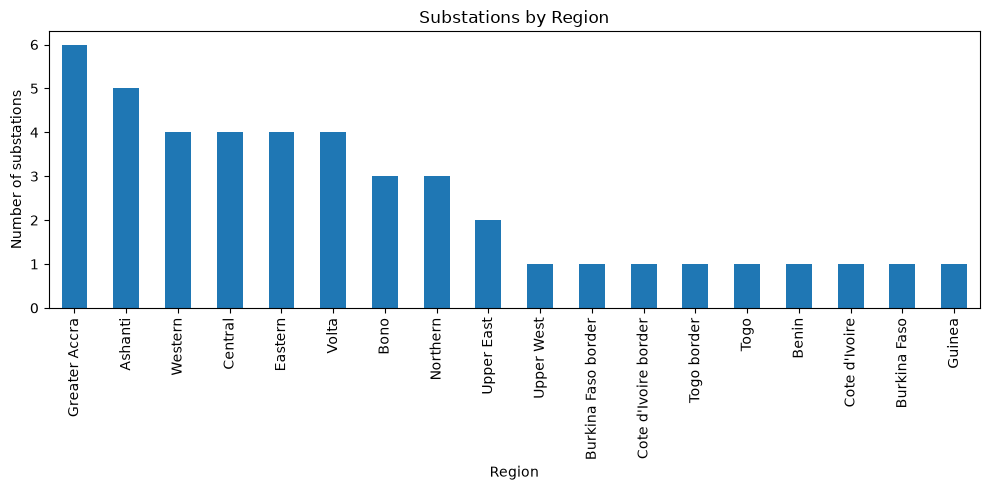

Region
Greater Accra           6
Ashanti                 5
Western                 4
Central                 4
Eastern                 4
Volta                   4
Bono                    3
Northern                3
Upper East              2
Upper West              1
Burkina Faso border     1
Cote d'Ivoire border    1
Togo border             1
Togo                    1
Benin                   1
Cote d'Ivoire           1
Burkina Faso            1
Guinea                  1
Name: count, dtype: int64

In [8]:
region_counts = substations["Region"].value_counts()
region_counts.plot(kind="bar", figsize=(10, 5), title="Substations by Region")
plt.ylabel("Number of substations")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "substations_by_region.png")
plt.show()
region_counts

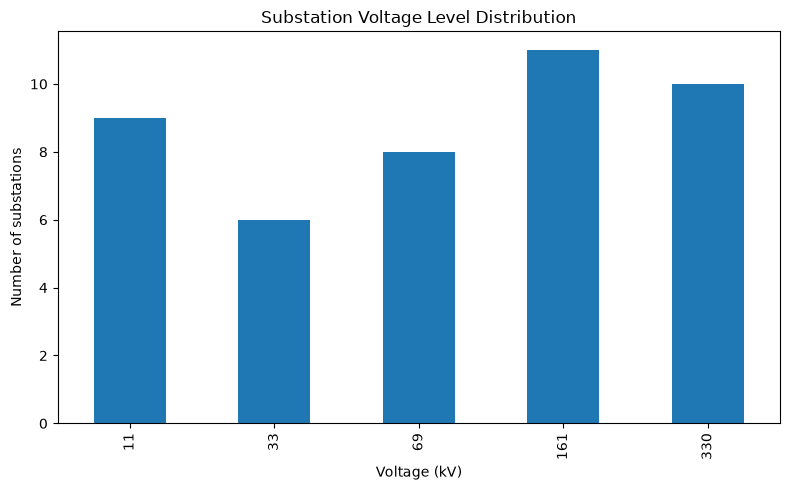

Voltage (kV)
11      9
33      6
69      8
161    11
330    10
Name: count, dtype: int64

In [9]:
voltage_counts = substations["Voltage (kV)"].value_counts().sort_index()
voltage_counts.plot(kind="bar", figsize=(8, 5), title="Substation Voltage Level Distribution")
plt.xlabel("Voltage (kV)")
plt.ylabel("Number of substations")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "voltage_distribution.png")
plt.show()
voltage_counts

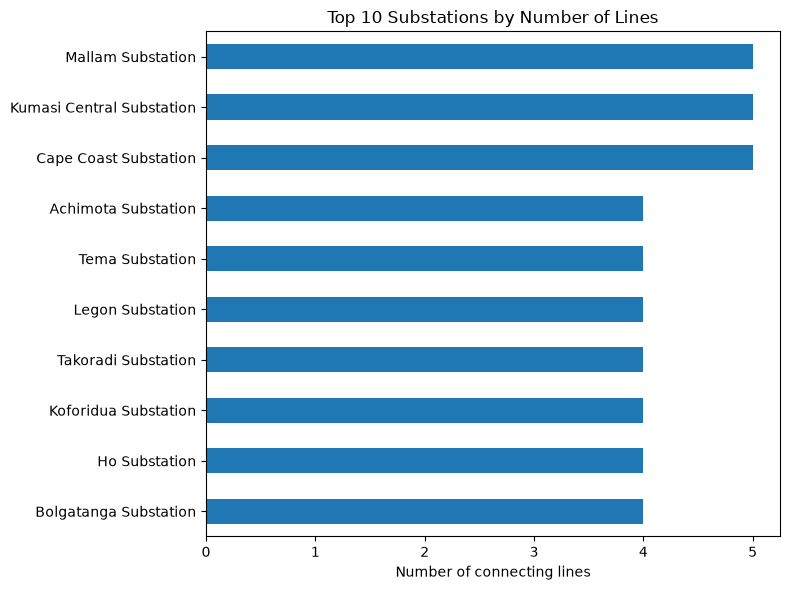

Mallam Substation            5
Kumasi Central Substation    5
Cape Coast Substation        5
Achimota Substation          4
Tema Substation              4
Legon Substation             4
Takoradi Substation          4
Koforidua Substation         4
Ho Substation                4
Bolgatanga Substation        4
Name: count, dtype: int64

In [10]:
connections = pd.concat([lines["Source Substation"], lines["Destination Substation"]])
top_substations = connections.value_counts().head(10)
top_substations.plot(kind="barh", figsize=(8, 6), title="Top 10 Substations by Number of Lines")
plt.xlabel("Number of connecting lines")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(CHARTS_DIR / "top_substations_by_lines.png")
plt.show()
top_substations

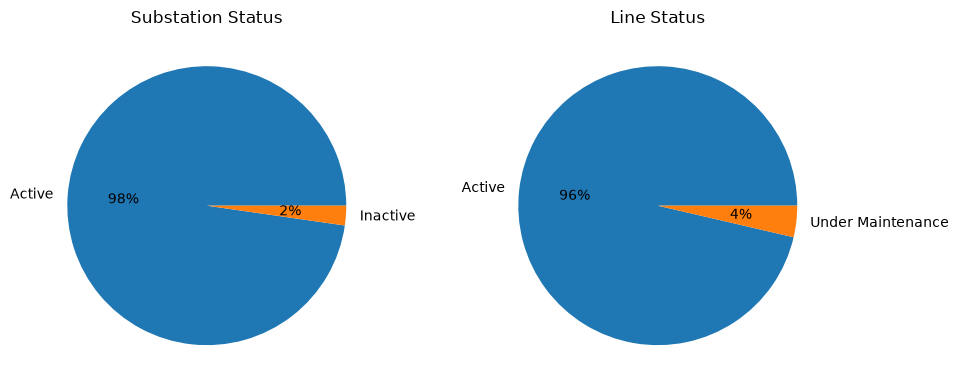

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
substations["Status"].value_counts().plot(kind="pie", autopct="%1.0f%%", ax=axes[0], title="Substation Status")
lines["Status"].value_counts().plot(kind="pie", autopct="%1.0f%%", ax=axes[1], title="Line Status")
for ax in axes:
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "status_counts.png")
plt.show()

## Notes and limitations

- All figures above are derived from a **synthetic**, seeded dataset generated for
  this coursework project. Coordinates, capacities, commissioning years, and
  connections are illustrative and must not be presented as real measurements
  of Ghana's actual electricity grid.
- The cleaning report above (missing values, coercion failures, duplicates,
  invalid coordinates, referential integrity) should be re-examined any time
  the underlying dataset changes, since real asset registers are rarely this
  clean.
- Continue to `02_network_analysis.ipynb` for the graph-based analysis.